# Phylogenetic Tree Viewer with Fossil Calibration Labels

Visualizes the phylogenetic tree from `strategy1.tree` with B() calibration annotations displayed on internal nodes.
Uses matplotlib only — rectangular cladogram layout (FigTree-style right-angle branches).

In [1]:
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path

TREE_FILE = Path("strategy1.tree")

# --- Toggle: True = dark background, False = light background ---
DARK_MODE = False

# --- Config ---
FONT_SIZE_LEAF = 11
FONT_SIZE_LABEL = 8
FIG_WIDTH = 20
LINE_WIDTH = 0.8
LEAF_FONT = "monospace"
LABEL_OFFSET_X = 0.15
NODE_DOT_SIZE = 18

# --- Theme-dependent colors ---
if DARK_MODE:
    BG_COLOR = "#1e1e1e"
    BRANCH_COLOR = "#aaaaaa"
    LEAF_TEXT_COLOR = "#e0e0e0"
    LABEL_TEXT_COLOR = "#eeeeee"
    LABEL_EDGE_ALPHA = 0.8
    LABEL_FACE_ALPHA = 0.35
    NODE_EDGE_COLOR = "#cccccc"
    ARROW_COLOR = "#777777"
    TITLE_COLOR = "#e0e0e0"
    CBAR_LABEL_COLOR = "#cccccc"
else:
    BG_COLOR = "#ffffff"
    BRANCH_COLOR = "#404040"
    LEAF_TEXT_COLOR = "#111111"
    LABEL_TEXT_COLOR = "#222222"
    LABEL_EDGE_ALPHA = 0.7
    LABEL_FACE_ALPHA = 0.25
    NODE_EDGE_COLOR = "black"
    ARROW_COLOR = "#999999"
    TITLE_COLOR = "#111111"
    CBAR_LABEL_COLOR = "#333333"

In [2]:
# --- Newick Parser (from fossil_calibrations.ipynb) ---

def parse_newick_with_calibrations(newick_str):
    """Parse a Newick string with 'B(min,max,p,c)' annotations.

    Returns:
        root: root node ID
        children: dict mapping node_id -> list of child node_ids
        leaf_name: dict mapping leaf node_id -> taxon name
        calibrations: dict mapping node_id -> (lower, upper)
    """
    s = newick_str.strip().rstrip(";")
    node_counter = 0
    children = {}
    leaf_name = {}
    calibrations = {}
    stack = []
    i = 0

    def new_node():
        nonlocal node_counter
        nid = node_counter
        node_counter += 1
        children[nid] = []
        return nid

    # Create root and skip opening '('
    root = new_node()
    stack.append(root)
    i = 1  # skip first '('

    while i < len(s):
        c = s[i]

        if c == "(":
            node = new_node()
            children[stack[-1]].append(node)
            stack.append(node)
            i += 1

        elif c == ",":
            i += 1

        elif c == ")":
            closed = stack.pop()
            i += 1
            # Check for 'B(...)' annotation
            if i < len(s) and s[i] == "'":
                end_quote = s.index("'", i + 1)
                annotation = s[i + 1 : end_quote]
                m = re.match(r"B\(([\d.]+),([\d.]+)", annotation)
                if m:
                    calibrations[closed] = (m.group(1), m.group(2))
                i = end_quote + 1
            # Skip optional branch length after ')' or after annotation
            if i < len(s) and s[i] == ":":
                i += 1
                while i < len(s) and s[i] not in "(),';":
                    i += 1

        elif c == ":":
            # Skip branch length
            i += 1
            while i < len(s) and s[i] not in "(),';":
                i += 1

        else:
            # Taxon name
            j = i
            while j < len(s) and s[j] not in "(),':":
                j += 1
            name = s[i:j].strip()
            if name:
                leaf = new_node()
                leaf_name[leaf] = name
                children[stack[-1]].append(leaf)
            i = j

    return root, children, leaf_name, calibrations


def get_leaves(node, children, leaf_name):
    """Recursively get all leaf taxon names under a node."""
    if node in leaf_name:
        return [leaf_name[node]]
    result = []
    for child in children[node]:
        result.extend(get_leaves(child, children, leaf_name))
    return result

In [3]:
# --- Tree Layout Algorithm ---

def get_traversal_order(node, children, leaf_name):
    """Return leaves in left-to-right tree order (preserves topology from Newick)."""
    if node in leaf_name:
        return [node]
    result = []
    for child in children[node]:
        result.extend(get_traversal_order(child, children, leaf_name))
    return result


def compute_depth(root, children):
    """Compute depth (number of edges from root) for every node via BFS."""
    depth = {root: 0}
    queue = [root]
    while queue:
        node = queue.pop(0)
        for child in children[node]:
            depth[child] = depth[node] + 1
            queue.append(child)
    return depth


def compute_layout(root, children, leaf_name, calibrations):
    """Compute (x, y) coordinates for every node.

    X = depth (root at 0, leaves at max depth on the right) -> cladogram.
    Y = leaf traversal order (preserves topology).
    Internal nodes: y = mean of children's y values.

    Returns: pos dict {node_id: (x, y)}, max_depth
    """
    # Compute depths
    depth = compute_depth(root, children)
    max_depth = max(depth.values())

    # Assign y positions to leaves in traversal order
    leaf_order = get_traversal_order(root, children, leaf_name)
    leaf_y = {}
    for idx, leaf_id in enumerate(leaf_order):
        leaf_y[leaf_id] = idx

    # For a cladogram: all leaves align at max_depth on x-axis
    pos = {}

    def assign_pos(node):
        if node in leaf_name:
            pos[node] = (max_depth, leaf_y[node])
            return leaf_y[node]
        child_ys = []
        for child in children[node]:
            cy = assign_pos(child)
            child_ys.append(cy)
        y = sum(child_ys) / len(child_ys)
        pos[node] = (depth[node], y)
        return y

    assign_pos(root)
    return pos, max_depth

In [4]:
# --- Tree Drawing Function ---

def draw_tree(root, children, leaf_name, calibrations, pos, max_depth, ax):
    """Draw the phylogenetic tree with calibration labels."""
    n_taxa = len(leaf_name)

    # Set background color
    ax.set_facecolor(BG_COLOR)
    ax.figure.set_facecolor(BG_COLOR)

    # Color map for calibrations based on midpoint age
    if calibrations:
        ages = [(float(lo) + float(hi)) / 2 for lo, hi in calibrations.values()]
        age_min, age_max = min(ages), max(ages)
        cmap = cm.get_cmap("coolwarm")
        norm = mcolors.Normalize(vmin=age_min, vmax=age_max)

    # --- Draw branches (rectangular / right-angle style) ---
    for node in children:
        if not children[node]:  # leaf
            continue
        px, py = pos[node]
        child_ys = [pos[c][1] for c in children[node]]
        # Vertical connector spanning all children
        ax.plot([px, px], [min(child_ys), max(child_ys)],
                color=BRANCH_COLOR, linewidth=LINE_WIDTH, solid_capstyle="round")
        # Horizontal connectors to each child
        for child in children[node]:
            cx, cy = pos[child]
            ax.plot([px, cx], [cy, cy],
                    color=BRANCH_COLOR, linewidth=LINE_WIDTH, solid_capstyle="round")

    # --- Draw leaf labels ---
    for leaf_id, name in leaf_name.items():
        lx, ly = pos[leaf_id]
        ax.text(lx + 0.2, ly, name.replace("_", " "),
                fontsize=FONT_SIZE_LEAF, fontfamily=LEAF_FONT,
                va="center", ha="left", fontstyle="italic",
                color=LEAF_TEXT_COLOR)

    # --- Draw calibration labels on internal nodes ---
    calib_list = sorted(calibrations.items(), key=lambda x: pos[x[0]][1])  # sort by y

    for idx, (node_id, (lower, upper)) in enumerate(calib_list, 1):
        nx, ny = pos[node_id]
        midpoint = (float(lower) + float(upper)) / 2
        color = cmap(norm(midpoint))

        # Colored dot on the node
        ax.scatter([nx], [ny], s=NODE_DOT_SIZE, color=color,
                   edgecolors=NODE_EDGE_COLOR, linewidths=0.4, zorder=5)

        # Label text
        label = f"[{idx}] B({lower},{upper})"

        # Place label to the left of the node with a slight offset
        ax.annotate(
            label,
            xy=(nx, ny),
            xytext=(nx - LABEL_OFFSET_X, ny + 0.35),
            fontsize=FONT_SIZE_LABEL,
            color=LABEL_TEXT_COLOR,
            fontweight="bold",
            ha="right",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor=mcolors.to_rgba(color, alpha=LABEL_FACE_ALPHA),
                edgecolor=mcolors.to_rgba(color, alpha=LABEL_EDGE_ALPHA),
                linewidth=0.6,
            ),
            arrowprops=dict(
                arrowstyle="-",
                color=ARROW_COLOR,
                linewidth=0.4,
            ),
            zorder=6,
        )

    # --- Styling ---
    ax.set_xlim(-1.5, max_depth + 4.5)
    ax.set_ylim(-1, n_taxa)
    ax.invert_yaxis()  # root at top
    ax.axis("off")

    # Colorbar for calibration ages
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.3, aspect=20, pad=0.01)
    cbar.set_label("Calibration midpoint (100 Ma)", fontsize=7, color=CBAR_LABEL_COLOR)
    cbar.ax.tick_params(labelsize=6, colors=CBAR_LABEL_COLOR)
    cbar.outline.set_edgecolor(CBAR_LABEL_COLOR)

Taxa: 54
Calibrations: 34
Theme: light
Max tree depth: 15


/tmp/ipykernel_3112413/3485944229.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm")



Saved: strategy1_tree.pdf, strategy1_tree.svg


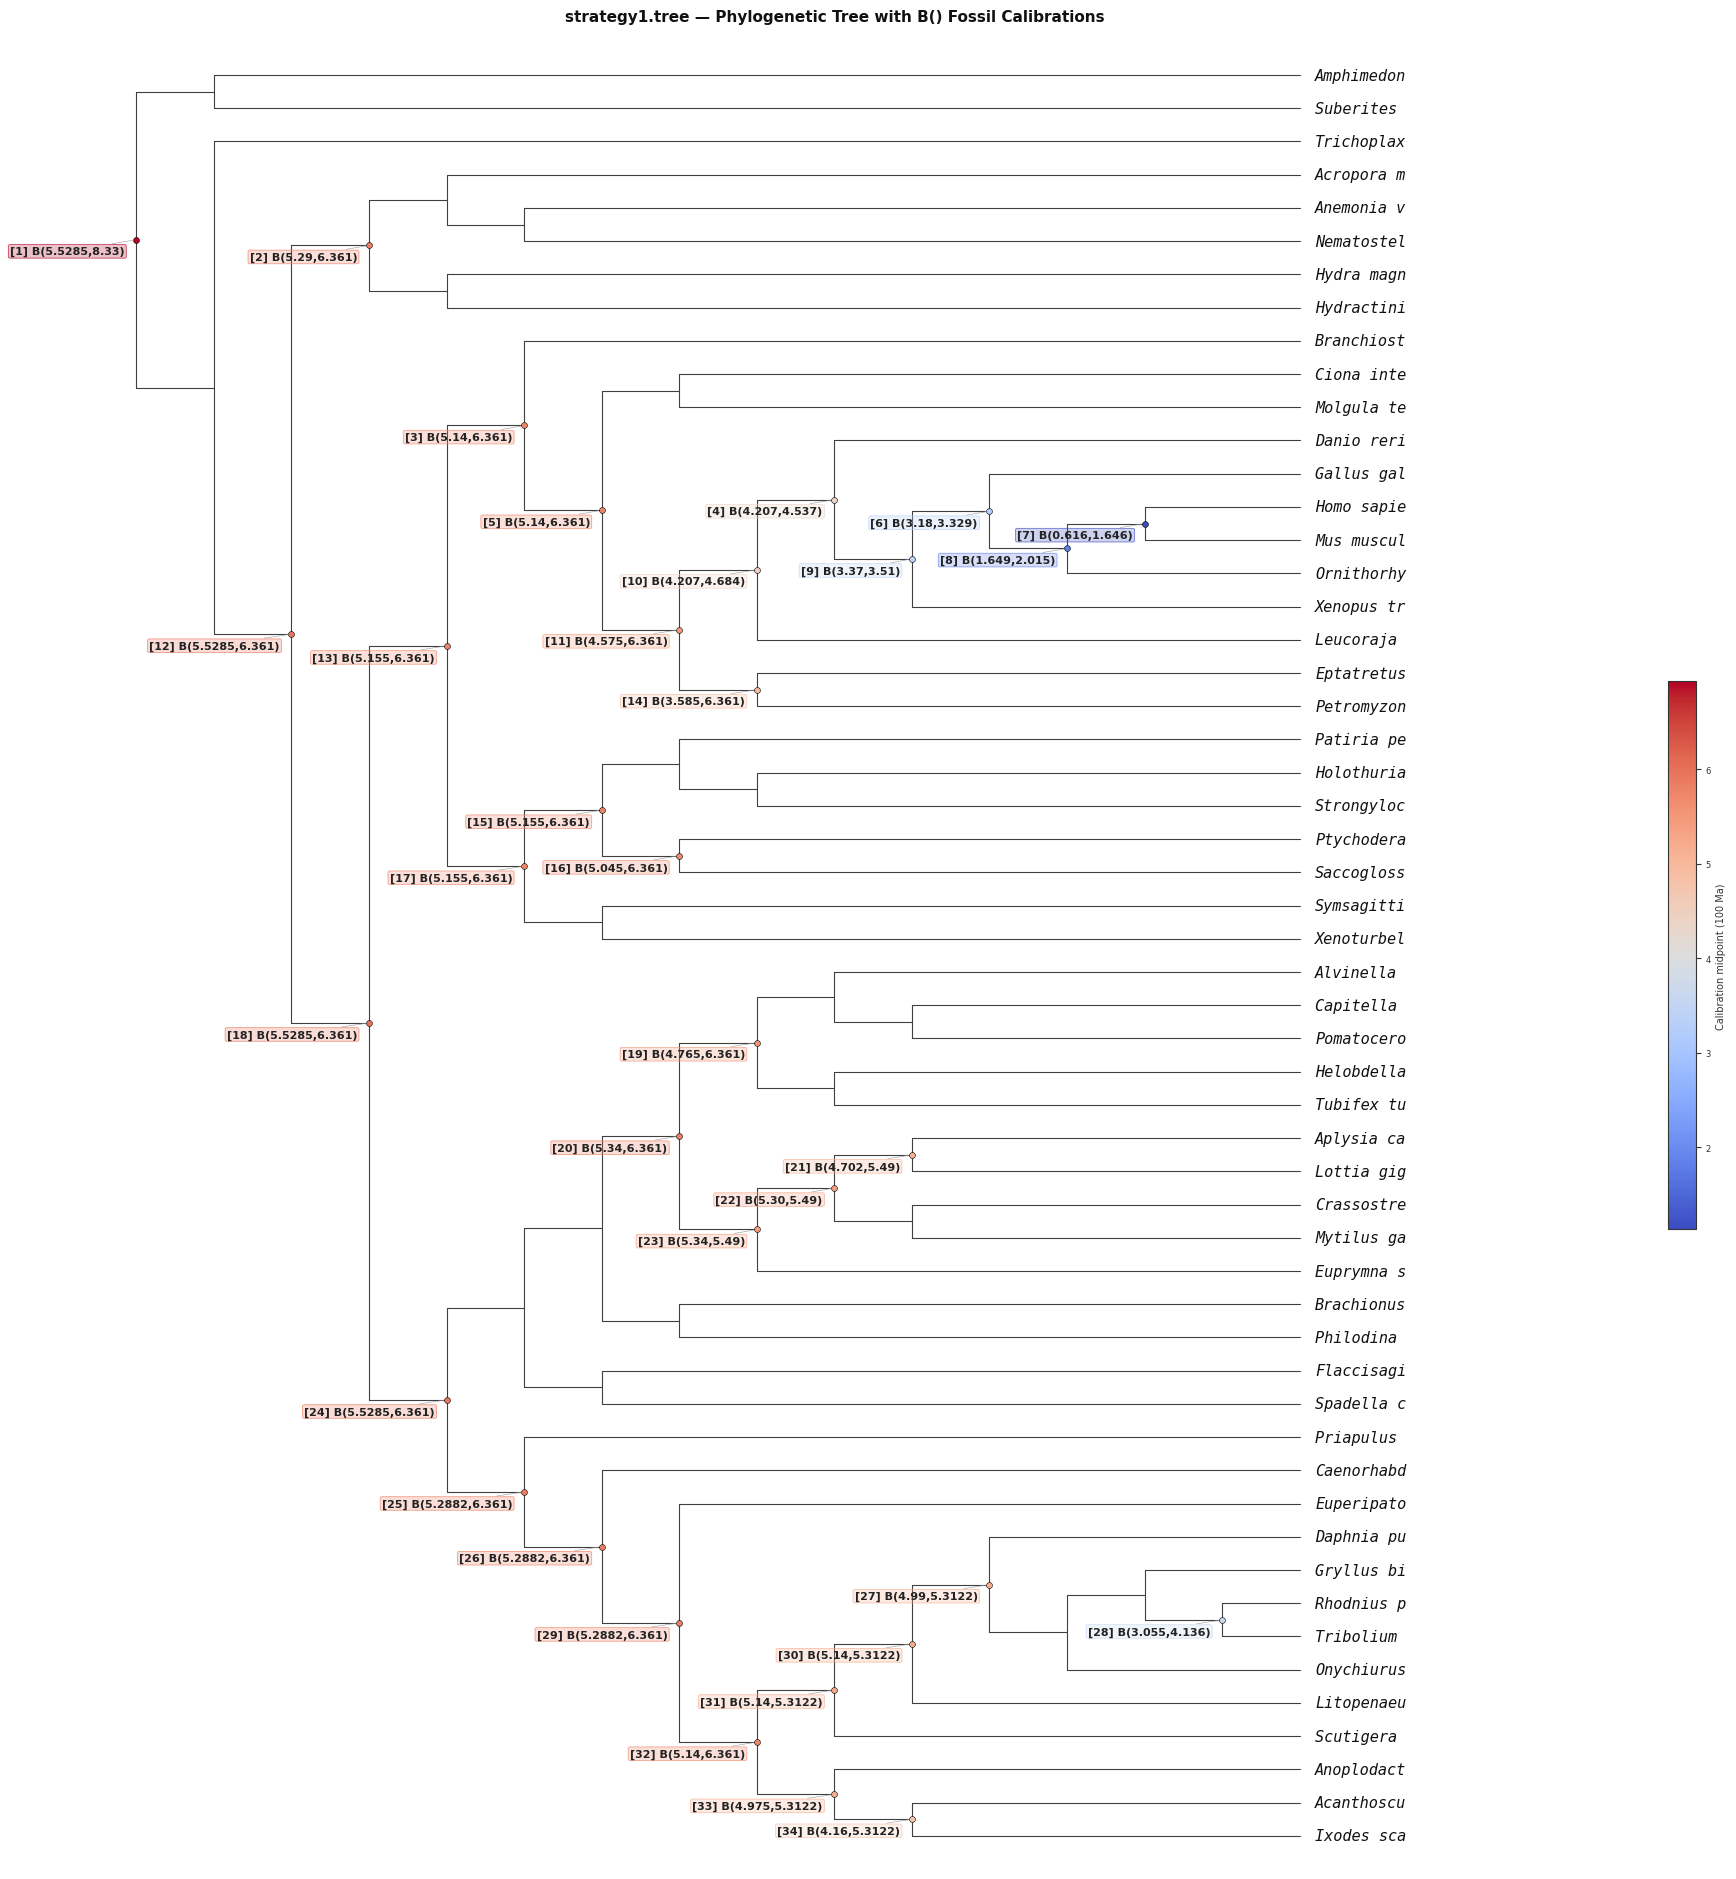

In [5]:
# --- Parse tree and compute layout ---
tree_str = TREE_FILE.read_text()
root, children, leaf_name, calibrations = parse_newick_with_calibrations(tree_str)

n_taxa = len(leaf_name)
print(f"Taxa: {n_taxa}")
print(f"Calibrations: {len(calibrations)}")
print(f"Theme: {'dark' if DARK_MODE else 'light'}")

pos, max_depth = compute_layout(root, children, leaf_name, calibrations)
print(f"Max tree depth: {max_depth}")

# --- Render ---
fig_height = max(12, n_taxa * 0.35)
fig, ax = plt.subplots(figsize=(FIG_WIDTH, fig_height))
draw_tree(root, children, leaf_name, calibrations, pos, max_depth, ax)
ax.set_title("strategy1.tree — Phylogenetic Tree with B() Fossil Calibrations",
             fontsize=11, fontweight="bold", pad=15, color=TITLE_COLOR)
plt.tight_layout()
plt.savefig("strategy1_tree.pdf", bbox_inches="tight", dpi=300, facecolor=BG_COLOR)
plt.savefig("strategy1_tree.svg", bbox_inches="tight", dpi=300, facecolor=BG_COLOR)
print("\nSaved: strategy1_tree.pdf, strategy1_tree.svg")
plt.show()

In [6]:
# --- Summary Table of Calibrations ---

all_taxa = sorted(set(leaf_name.values()))

# Build calibration table with clade info
calib_list_sorted = sorted(calibrations.items(), key=lambda x: pos[x[0]][1])

print(f"{'#':<4} {'Clade (first & last taxon)':<45} {'B(lower,upper)':<22} {'#Taxa':>6}")
print("-" * 80)

for idx, (node_id, (lower, upper)) in enumerate(calib_list_sorted, 1):
    taxa = sorted(get_leaves(node_id, children, leaf_name))
    n = len(taxa)
    if n == len(all_taxa):
        clade = "root (all taxa)"
    elif n <= 3:
        clade = ", ".join(taxa)
    else:
        clade = f"{taxa[0]} ... {taxa[-1]}"
    print(f"{idx:<4} {clade:<45} B({lower},{upper}){'':<5} {n:>6}")

print(f"\nTotal: {len(calibrations)} calibrations across {n_taxa} taxa")

#    Clade (first & last taxon)                    B(lower,upper)          #Taxa
--------------------------------------------------------------------------------
1    root (all taxa)                               B(5.5285,8.33)          54
2    Acropora_m ... Nematostel                     B(5.29,6.361)           5
3    Branchiost ... Xenopus_tr                     B(5.14,6.361)          12
4    Danio_reri ... Xenopus_tr                     B(4.207,4.537)           6
5    Ciona_inte ... Xenopus_tr                     B(5.14,6.361)          11
6    Gallus_gal ... Ornithorhy                     B(3.18,3.329)           4
7    Homo_sapie, Mus_muscul                        B(0.616,1.646)           2
8    Homo_sapie, Mus_muscul, Ornithorhy            B(1.649,2.015)           3
9    Gallus_gal ... Xenopus_tr                     B(3.37,3.51)           5
10   Danio_reri ... Xenopus_tr                     B(4.207,4.684)           7
11   Danio_reri ... Xenopus_tr                     B(4.575,6.361